In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

rfm = pd.read_csv('../data/processed/rfm_segmented.csv')

rfm['Churned'] = (rfm['Recency'] > 307).astype(int)
rfm['Churned'].value_counts(normalize=True)

Churned
0    0.750109
1    0.249891
Name: proportion, dtype: float64

In [2]:
from sklearn.model_selection import train_test_split

features = ['Frequency', 'Monetary']
X = rfm[features]
y = rfm['Churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))

(16512, 2) (4129, 2)
Churned
0    0.750121
1    0.249879
Name: proportion, dtype: float64


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.75      0.99      0.85      3097
           1       0.06      0.00      0.00      1032

    accuracy                           0.74      4129
   macro avg       0.40      0.50      0.43      4129
weighted avg       0.58      0.74      0.64      4129

ROC AUC: 0.6666111303011416


In [4]:
class_weight='balanced'

In [5]:
log_model_balanced = LogisticRegression(random_state=42, class_weight='balanced')
log_model_balanced.fit(X_train, y_train)

y_pred_bal = log_model_balanced.predict(X_test)
y_proba_bal = log_model_balanced.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_bal))
print("ROC AUC:", roc_auc_score(y_test, y_proba_bal))

              precision    recall  f1-score   support

           0       0.81      0.64      0.72      3097
           1       0.34      0.56      0.42      1032

    accuracy                           0.62      4129
   macro avg       0.58      0.60      0.57      4129
weighted avg       0.70      0.62      0.64      4129

ROC AUC: 0.6673004069955171


In [6]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

           0       0.85      0.81      0.83      3097
           1       0.49      0.56      0.52      1032

    accuracy                           0.75      4129
   macro avg       0.67      0.68      0.68      4129
weighted avg       0.76      0.75      0.75      4129

ROC AUC: 0.8092000448045497


In [7]:
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

Monetary     0.827701
Frequency    0.172299
dtype: float64


In [8]:
df = pd.read_csv('../data/raw/DataCoSupplyChainDataset.csv', encoding='latin1')
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])

tenure = df.groupby('Customer Id')['order date (DateOrders)'].agg(['min', 'max'])
tenure['Tenure'] = (tenure['max'] - tenure['min']).dt.days
tenure = tenure[['Tenure']].reset_index()

rfm = rfm.merge(tenure, on='Customer Id', how='left')
rfm['Tenure'].describe()

count    20641.000000
mean       352.771135
std        353.389212
min          0.000000
25%          0.000000
50%        306.000000
75%        699.000000
max       1003.000000
Name: Tenure, dtype: float64

In [9]:
features2 = ['Frequency', 'Monetary', 'Tenure']
X2 = rfm[features2]
y2 = rfm['Churned']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

rf_model2 = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)
rf_model2.fit(X2_train, y2_train)

y2_pred = rf_model2.predict(X2_test)
y2_proba = rf_model2.predict_proba(X2_test)[:, 1]

print(classification_report(y2_test, y2_pred))
print("ROC AUC:", roc_auc_score(y2_test, y2_proba))

              precision    recall  f1-score   support

           0       0.93      0.84      0.88      3097
           1       0.62      0.80      0.70      1032

    accuracy                           0.83      4129
   macro avg       0.77      0.82      0.79      4129
weighted avg       0.85      0.83      0.84      4129

ROC AUC: 0.9019592291114432


In [10]:
importances2 = pd.Series(rf_model2.feature_importances_, index=features2).sort_values(ascending=False)
print(importances2)

import joblib
joblib.dump(rf_model2, '../data/processed/churn_model.pkl')
rfm.to_csv('../data/processed/rfm_final.csv', index=False)

Tenure       0.443899
Monetary     0.435409
Frequency    0.120692
dtype: float64


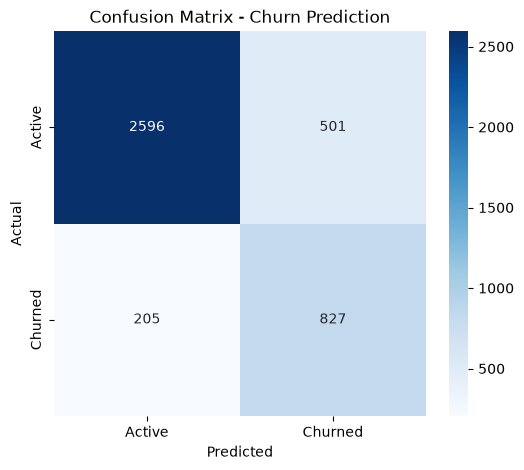

In [11]:
cm = confusion_matrix(y2_test, y2_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Active', 'Churned'], yticklabels=['Active', 'Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Churn Prediction')
plt.savefig('../data/processed/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
rfm['CLV_proxy'] = rfm['Monetary'] * rfm['Frequency']
rfm['CLV_proxy'].describe()

count     20641.000000
mean       9468.897872
std       13536.855107
min          11.290000
25%         293.040008
50%        3399.720047
75%       14217.960274
max      136814.212309
Name: CLV_proxy, dtype: float64

In [14]:
import xgboost
print(xgboost.__version__)

3.4.1


In [15]:
from xgboost import XGBClassifier

scale_pos_weight = (y2_train == 0).sum() / (y2_train == 1).sum()

xgb_model = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight, eval_metric='logloss')
xgb_model.fit(X2_train, y2_train)

y2_pred_xgb = xgb_model.predict(X2_test)
y2_proba_xgb = xgb_model.predict_proba(X2_test)[:, 1]

print(classification_report(y2_test, y2_pred_xgb))
print("ROC AUC:", roc_auc_score(y2_test, y2_proba_xgb))

              precision    recall  f1-score   support

           0       0.96      0.80      0.88      3097
           1       0.60      0.91      0.73      1032

    accuracy                           0.83      4129
   macro avg       0.78      0.85      0.80      4129
weighted avg       0.87      0.83      0.84      4129

ROC AUC: 0.9068583187530819


In [16]:
rfm['Churn_Probability'] = xgb_model.predict_proba(rfm[features2])[:, 1]

import joblib
joblib.dump(xgb_model, '../data/processed/churn_model_xgb.pkl')
rfm.to_csv('../data/processed/rfm_final.csv', index=False)

rfm[['Customer Id', 'Segment', 'CLV_proxy', 'Churn_Probability']].head()

,Customer Id,Segment,CLV_proxy,Churn_Probability
0,1,At Risk / Churned,499.950012,0.911394
1,2,Loyal / High-Value,7278.920135,0.226501
2,3,Loyal / High-Value,17688.400469,0.797670
3,4,At Risk / Churned,6878.520119,0.876547
4,5,At Risk / Churned,3824.250069,0.944738


In [17]:
import sqlite3

conn = sqlite3.connect('../data/processed/churn_project.db')
df.to_sql('orders', conn, if_exists='replace', index=False)
rfm.to_sql('customer_summary', conn, if_exists='replace', index=False)

pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)

,name
0,orders
1,customer_summary


In [18]:
query_rfm = """
SELECT 
    "Customer Id",
    COUNT(DISTINCT "Order Id") AS Frequency,
    SUM(Sales) AS Monetary,
    MAX("order date (DateOrders)") AS Last_Order_Date
FROM orders
GROUP BY "Customer Id"
ORDER BY Monetary DESC
LIMIT 10
"""

pd.read_sql(query_rfm, conn)

,Customer Id,Frequency,Monetary,Last_Order_Date
0,791,13,10524.170178,2017-09-26 01:13:00
1,9371,11,9299.030207,2017-09-06 22:58:00
2,8766,11,9296.140186,2017-09-19 16:07:00
3,1657,11,9223.710152,2017-06-07 14:52:00
4,2641,11,9130.920224,2017-08-07 00:56:00
5,1288,12,9019.110199,2017-05-22 12:47:00
6,3710,14,9019.100208,2017-08-04 01:28:00
7,4249,13,8918.850134,2017-08-18 11:37:00
8,5654,15,8904.950211,2017-10-01 04:54:00
9,5624,12,8761.980183,2017-09-24 08:35:00


In [19]:
query_segments = """
SELECT 
    Segment,
    COUNT(*) AS Customer_Count,
    ROUND(AVG(Recency), 1) AS Avg_Recency,
    ROUND(AVG(Frequency), 1) AS Avg_Frequency,
    ROUND(AVG(Monetary), 2) AS Avg_Monetary,
    ROUND(AVG(CLV_proxy), 2) AS Avg_CLV,
    ROUND(AVG(Churn_Probability), 3) AS Avg_Churn_Risk
FROM customer_summary
GROUP BY Segment
ORDER BY Avg_CLV DESC
"""

pd.read_sql(query_segments, conn)

,Segment,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_CLV,Avg_Churn_Risk
0,Loyal / High-Value,7568,254.1,5.9,3573.79,22685.04,0.405
1,At Risk / Churned,4648,450.2,2.7,1554.33,4571.35,0.760
2,Recent One-Time Buyer,5292,73.0,1.0,438.22,439.94,0.035
3,New Customer,1510,11.0,1.0,86.02,86.02,0.023
4,New / Low-Value,1623,77.8,1.0,37.84,37.84,0.020
